# Hệ Thống Gợi Ý Phim Hybrid

Cấu trúc thư mục:

```text
RECOMMENDATION_SYSTEM/
├── data/
├── models/
├── app.py
├── data_loader.py
├── evaluation.py
└── recommender.py
```

Luồng:

```text
Train offline một lần → lưu data processed + model .pkl → Streamlit load lại → rating mới cập nhật realtime vào CBF profile → CF không retrain ngay
```


## **1. Import Libraries**

In [ ]:
# Import thư viện cần thiết
import os
import ast
import pickle
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

print("Import libraries thanh cong")


Import libraries thanh cong


## **2. Load Data**

Ưu tiên đọc dữ liệu từ thư mục `data/` của project để đồng bộ với Streamlit app. Nếu chạy trên Colab thì có thể fallback sang Drive.


In [ ]:
from pathlib import Path
import os
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    PROJECT_DIR = Path('/content/drive/MyDrive/RECOMMENDATION_SYSTEM')
else:
    PROJECT_DIR = Path.cwd()

DATA_DIR = PROJECT_DIR / 'data'
MODELS_DIR = PROJECT_DIR / 'models'
DATA_PATH = DATA_DIR

if not DATA_DIR.exists():
    raise FileNotFoundError(f'Không tìm thấy thư mục data/: {DATA_DIR}')

MODELS_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT_DIR)

print(f"PROJECT_DIR: {PROJECT_DIR}")
print(f"DATA_PATH: {DATA_PATH}")
print(f"MODELS_DIR: {MODELS_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR: /content/drive/MyDrive/RECOMMENDATION_SYSTEM
DATA_PATH: /content/drive/MyDrive/RECOMMENDATION_SYSTEM/data
MODELS_DIR: /content/drive/MyDrive/RECOMMENDATION_SYSTEM/models


In [ ]:
# Kiem tra file du lieu dau vao bat buoc
required_files = [
    'ratings.csv',
    'movies.csv',
    'links.csv',
    'tmdb_5000_movies.csv',
    'tmdb_5000_credits.csv'
]

missing_files = [f for f in required_files if not (DATA_PATH / f).exists()]

if missing_files:
    print('Thieu file du lieu:')
    for f in missing_files:
        print('   -', f)
    print('\nHay dat cac file tren vao thu muc data/ cua project.')
else:
    print('Du file du lieu dau vao')
    print(os.listdir(DATA_PATH))


Du file du lieu dau vao
['tmdb_5000_movies.csv', 'ratings.csv', 'tmdb_5000_credits.csv', 'movies.csv', 'links.csv', 'movie_meta_processed.csv', 'final_ratings_processed.csv']


In [ ]:
ratings = pd.read_csv(DATA_PATH / 'ratings.csv')
movies = pd.read_csv(DATA_PATH / 'movies.csv')
links = pd.read_csv(DATA_PATH / 'links.csv')

print("Thong tin dataset:")
print(f"  - So phim: {len(movies)}")
print(f"  - So ratings: {len(ratings)}")
print(f"  - So users: {ratings['userId'].nunique()}")
print(f"  - Rating trung binh: {ratings['rating'].mean():.2f}")

display(movies.head())
display(ratings.head())


Thong tin dataset:
  - So phim: 9742
  - So ratings: 100836
  - So users: 610
  - Rating trung binh: 3.50


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## **3. Exploratory Data Analysis (EDA)**

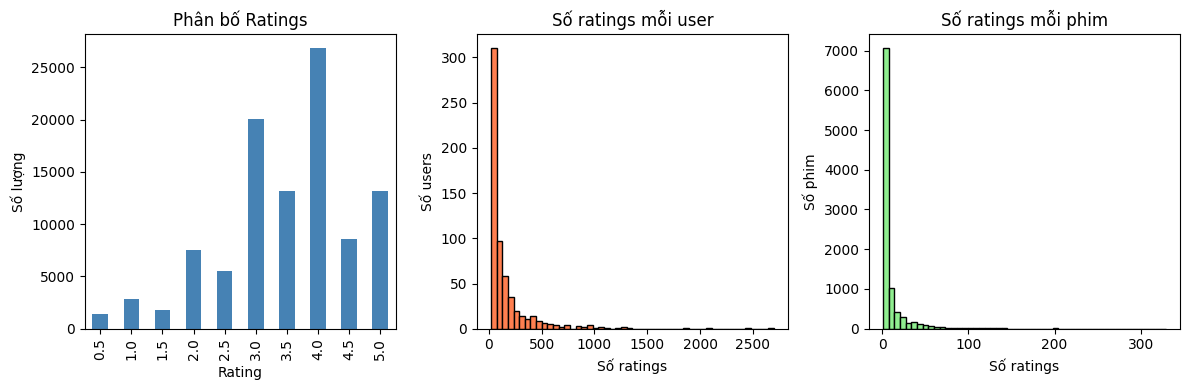

In [ ]:
# Phân bố ratings
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
ratings['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Phân bố Ratings')
plt.xlabel('Rating')
plt.ylabel('Số lượng')

plt.subplot(1, 3, 2)
ratings_per_user = ratings.groupby('userId').size()
plt.hist(ratings_per_user, bins=50, color='coral', edgecolor='black')
plt.title('Số ratings mỗi user')
plt.xlabel('Số ratings')
plt.ylabel('Số users')

plt.subplot(1, 3, 3)
ratings_per_movie = ratings.groupby('movieId').size()
plt.hist(ratings_per_movie, bins=50, color='lightgreen', edgecolor='black')
plt.title('Số ratings mỗi phim')
plt.xlabel('Số ratings')
plt.ylabel('Số phim')

plt.tight_layout()
plt.show()

## **4. Data Preprocessing**



In [ ]:
import ast

# Đọc dữ liệu TMDB
movies_tmdb = pd.read_csv(DATA_PATH / 'tmdb_5000_movies.csv')
credits_tmdb = pd.read_csv(DATA_PATH / 'tmdb_5000_credits.csv')

tmdb_movies = movies_tmdb.merge(
    credits_tmdb,
    left_on='id',
    right_on='movie_id'
)

tmdb_movies = tmdb_movies[['id', 'title_x', 'overview', 'genres', 'keywords', 'cast', 'crew']]
tmdb_movies = tmdb_movies.rename(columns={'title_x': 'title'})

#Xu ly missing value
tmdb_movies['overview'] = tmdb_movies['overview'].fillna('')
#Overview neu khong co se gan la ''
#Cac cot genres, keywords, cast, crew la cac chuoi json => neu khong co thi gan la []
#vi neu de NaN thi se bi loi o ham ast.literal_eval()
tmdb_movies['genres'] = tmdb_movies['genres'].fillna('[]')
tmdb_movies['keywords'] = tmdb_movies['keywords'].fillna('[]')
tmdb_movies['cast'] = tmdb_movies['cast'].fillna('[]')
tmdb_movies['crew'] = tmdb_movies['crew'].fillna('[]')

#Ham lay truong the loai phim
def fetch_names(text):
    try:
        return [i['name'] for i in ast.literal_eval(text)]
    except:
        return []
#Ham lay 3 dien vien dau cua phim vi cac dien vien dau thuong la dien vien chinh
def fetch_top3_cast(text):
    try:
        return [i['name'] for i in ast.literal_eval(text)][:3]
    except:
        return []
#Ham lay ra ten dao
def fetch_director(text):
    try:
        return [i['name'] for i in ast.literal_eval(text) if i.get('job') == 'Director']
    except:
        return []

tmdb_movies['genres'] = tmdb_movies['genres'].apply(fetch_names)
tmdb_movies['keywords'] = tmdb_movies['keywords'].apply(fetch_names)
tmdb_movies['cast'] = tmdb_movies['cast'].apply(fetch_top3_cast)
tmdb_movies['crew'] = tmdb_movies['crew'].apply(fetch_director)
#Tach overview thanh cac tu de sau nay cong voi genresm keywords,.. de gop thanh
tmdb_movies['overview'] = tmdb_movies['overview'].apply(lambda x: x.split())
#Xoa khoang trang de mo hinh hieu sai ten riengg hoac cum tu. VD: Tom Cruise -> TomCruise
for col in ['genres', 'keywords', 'cast', 'crew']:
    tmdb_movies[col] = tmdb_movies[col].apply(lambda x: [i.replace(" ", "") for i in x])
#Gop cac dac trung noi dung cua phim thanh 1 list duy nhat
tmdb_movies['tags'] = (
    tmdb_movies['overview'] +
    tmdb_movies['genres'] +
    tmdb_movies['keywords'] +
    tmdb_movies['cast'] +
    tmdb_movies['crew']
)

#Bien tag thanh mot chuoi van ban
tmdb_movies['tags'] = tmdb_movies['tags'].apply(lambda x: " ".join(x).lower())

# Tích hợp MovieLens với TMDB
links_clean = links.rename(columns={'tmdbId': 'id'}).copy()
links_clean = links_clean.dropna(subset=['id'])
links_clean['id'] = links_clean['id'].astype(int)

# Tạo bảng metadata chung
movie_meta = links_clean[['movieId', 'id']].merge(
    tmdb_movies[['id', 'title', 'tags']],
    on='id',
    how='inner'
)

# Lọc rating hợp lệ
final_ratings = ratings[ratings['movieId'].isin(movie_meta['movieId'])].copy()

print("Hoan thanh tich hop du lieu")
print(f"  - So phim dung duoc cho Hybrid: {len(movie_meta)}")
print(f"  - So luot rating hop le: {len(final_ratings)}")

movie_meta.head(), final_ratings.head()

# Tạo thư mục DATA_DIR nếu chưa tồn tại
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Lưu dữ liệu đã xử lý để Streamlit app dùng trực tiếp
movie_meta.to_csv(DATA_DIR / 'movie_meta_processed.csv', index=False)
final_ratings.to_csv(DATA_DIR / 'final_ratings_processed.csv', index=False)

print(f"Da luu: {DATA_DIR / 'movie_meta_processed.csv'}")
print(f"Da luu: {DATA_DIR / 'final_ratings_processed.csv'}")

Hoan thanh tich hop du lieu
  - So phim dung duoc cho Hybrid: 2344
  - So luot rating hop le: 40475
Da luu: /content/drive/MyDrive/RECOMMENDATION_SYSTEM/data/movie_meta_processed.csv
Da luu: /content/drive/MyDrive/RECOMMENDATION_SYSTEM/data/final_ratings_processed.csv


## **5. Content Based**

### 5.1 TF - IDF

In [ ]:
# TF-IDF
print("Ap dung TF-IDF")
tfidf = TfidfVectorizer(max_features = 3000, stop_words='english')
tfidf_matrix = tfidf.fit_transform(movie_meta['tags'])
print(f"  - TF-IDF matrix shape: {tfidf_matrix.shape}")

Ap dung TF-IDF
  - TF-IDF matrix shape: (2344, 3000)


### 5.2. Truncated SVD (Dimensionality Reduction)

Truncated SVD
  - So components su dung: 1000
  - Reduced features shape: (2344, 1000)
  - Luong thong tin giu lai: 82.73%


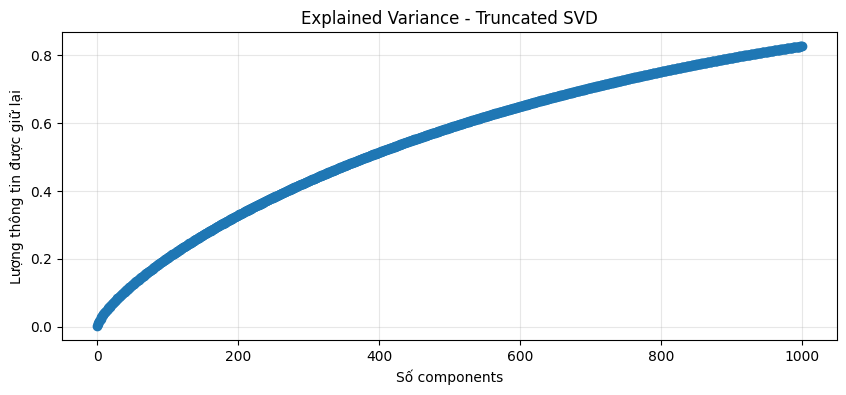

In [ ]:
print("Truncated SVD")

n_components = min(1000, tfidf_matrix.shape[1] - 1)

svd_content = TruncatedSVD(
    n_components=n_components,
    random_state=42
)

content_features = svd_content.fit_transform(tfidf_matrix)

explained_info = svd_content.explained_variance_ratio_.sum() * 100

print(f"  - So components su dung: {n_components}")
print(f"  - Reduced features shape: {content_features.shape}")
print(f"  - Luong thong tin giu lai: {explained_info:.2f}%")

plt.figure(figsize=(10, 4))
plt.plot(np.cumsum(svd_content.explained_variance_ratio_), marker='o')
plt.xlabel('Số components')
plt.ylabel('Lượng thông tin được giữ lại')
plt.title('Explained Variance - Truncated SVD')
plt.grid(True, alpha=0.3)
plt.show()

### 5.3. Cosine Similarity

In [ ]:
print("Tinh Cosine Similarity")

content_similarity = cosine_similarity(content_features)

print(f"  - Similarity matrix shape: {content_similarity.shape}")
print(f"  - So phim duoc so sanh: {content_similarity.shape[0]}")

print("\nHoan thanh Content-Based Model")

Tinh Cosine Similarity
  - Similarity matrix shape: (2344, 2344)
  - So phim duoc so sanh: 2344

Hoan thanh Content-Based Model


### 5.4. Content-Based Recommendations Function

In [ ]:
# Reset index để content_similarity và movie_meta khớp vị trí dòng
movie_meta = movie_meta.reset_index(drop=True)

# Tạo mapping: title -> index
indices = pd.Series(movie_meta.index, index=movie_meta['title']).drop_duplicates()

def get_content_based_recommendations(movie_title, top_n=10):
    movie_title = movie_title.strip().lower()

    matches = movie_meta[
        movie_meta['title'].str.lower().str.contains(movie_title, na=False)
    ]

    if matches.empty:
        print(f"Khong tim thay phim: {movie_title}")
        return pd.DataFrame()

    idx = matches.index[0]

    sim_scores = list(enumerate(content_similarity[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]

    movie_indices = [i[0] for i in sim_scores]
    similarity_scores = [i[1] for i in sim_scores]

    recommendations = movie_meta.iloc[movie_indices][['movieId', 'id', 'title']].copy()
    recommendations['similarity_score'] = similarity_scores
    recommendations['rank'] = range(1, len(recommendations) + 1)

    return recommendations[['rank', 'movieId', 'id', 'title', 'similarity_score']]


### 5.5. Test Content-Based Recommendations

In [ ]:
# Test với Toy Story
movie_title = "Cat People"
display(get_content_based_recommendations(movie_title, top_n=10))


,rank,movieId,id,title,similarity_score
2186,1,110591,157547,Oculus,0.292663
880,2,4517,49365,Lady in White,0.204951
1943,3,84772,39513,Paul,0.183223
1111,4,6158,14873,The Jungle Book 2,0.181823
2188,5,110773,184345,A Haunted House 2,0.180258
2318,6,151315,323675,Ride Along 2,0.178104
292,7,1571,11956,When the Cat's Away,0.176298
1697,8,58975,11152,The Ruins,0.166037
2307,9,143472,244316,Into the Grizzly Maze,0.164734
2247,10,122884,280092,Insidious: Chapter 3,0.163458


## **6. Collaborative Filtering**

### 6.1 Chuẩn bị dữ liệu


In [ ]:
from sklearn.model_selection import train_test_split

train_ratings, test_ratings = train_test_split(
    final_ratings,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Sử dụng train_ratings để train mô hình CF
# final_ratings chỉ dùng để chia train/test, không train trực tiếp trên toàn bộ dữ liệu
cf_data = train_ratings[['userId', 'movieId', 'rating']].copy()

# Encode userId và movieId về chỉ số liên tục từ 0
user_ids = cf_data['userId'].unique()
movie_ids = cf_data['movieId'].unique()

# Ánh xạ userId, movieId -> chỉ số liên tục 0, 1, 2, ...
user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
movie_to_idx = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}

# Ánh xạ ngược lại index -> userId, movieId
idx_to_user = {idx: user_id for user_id, idx in user_to_idx.items()}
idx_to_movie = {idx: movie_id for movie_id, idx in movie_to_idx.items()}

# Tạo cột user_idx và movie_idx để mô hình truy cập vào ma trận P, Q
cf_data['user_idx'] = cf_data['userId'].map(user_to_idx)
cf_data['movie_idx'] = cf_data['movieId'].map(movie_to_idx)

print("Chuan bi du lieu CF xong")
print(f"So user trong train: {len(user_ids)}")
print(f"So phim trong train: {len(movie_ids)}")
print(f"So rating train: {len(cf_data)}")
print(f"So rating test: {len(test_ratings)}")

Chuan bi du lieu CF xong
So user trong train: 609
So phim trong train: 2264
So rating train: 32380
So rating test: 8095


### 6.2. Khởi tạo P,Q,Bias

In [ ]:

num_users = len(user_ids)
num_movies = len(movie_ids)
num_factors = 40
learning_rate = 0.005
reg = 0.01
epochs = 40

SVD_MODEL_PATH = MODELS_DIR / 'svd_model.pkl'
LOAD_PRETRAINED_MF = False

if SVD_MODEL_PATH.exists():
    with open(SVD_MODEL_PATH, 'rb') as f:
        pretrained_mf = pickle.load(f)

    required_mf_keys = {'P', 'Q', 'bu', 'bi', 'mu', 'user_to_idx', 'movie_to_idx', 'idx_to_movie'}
    LOAD_PRETRAINED_MF = isinstance(pretrained_mf, dict) and required_mf_keys.issubset(pretrained_mf.keys())

    if not LOAD_PRETRAINED_MF:
        model_type = pretrained_mf.get('model_type', 'unknown') if isinstance(pretrained_mf, dict) else type(pretrained_mf).__name__
        print(f'Bo qua models/svd_model.pkl vi khong phai format MF-SGD cua phan 6 (model_type={model_type}).')
        print('Cell nay se khoi tao MF-SGD moi va train o cell tiep theo.')

if LOAD_PRETRAINED_MF:

    P = pretrained_mf['P']
    Q = pretrained_mf['Q']
    bu = pretrained_mf['bu']
    bi = pretrained_mf['bi']
    mu = pretrained_mf['mu']
    user_to_idx = pretrained_mf['user_to_idx']
    movie_to_idx = pretrained_mf['movie_to_idx']
    idx_to_user = pretrained_mf.get('idx_to_user', {idx: user_id for user_id, idx in user_to_idx.items()})
    idx_to_movie = pretrained_mf['idx_to_movie']
    num_factors = pretrained_mf.get('num_factors', P.shape[1])

    # ??ng b? l?i danh s?ch user/movie v?i model ?? load
    user_ids = np.array(list(user_to_idx.keys()))
    movie_ids = np.array(list(movie_to_idx.keys()))

    print('Da load MF model co san tu models/svd_model.pkl')
else:
    # Rating trung bình toàn hệ thống
    mu = cf_data['rating'].mean()

    # Tạo ngẫu nhiên ma trận P và Q
    np.random.seed(42)
    P = np.random.normal(0, 0.1, size=(num_users, num_factors))
    Q = np.random.normal(0, 0.1, size=(num_movies, num_factors))
    bu = np.zeros(num_users)
    bi = np.zeros(num_movies)

    print('Chua co model luu san, se khoi tao moi va train o cell tiep theo')

print(f'P shape: {P.shape}')
print(f'Q shape: {Q.shape}')
print(f'Global mean rating mu: {mu:.4f}')

Bo qua models/svd_model.pkl vi khong phai format MF-SGD cua phan 6 (model_type=als_implicit).
Cell nay se khoi tao MF-SGD moi va train o cell tiep theo.
Chua co model luu san, se khoi tao moi va train o cell tiep theo
P shape: (609, 40)
Q shape: (2264, 40)
Global mean rating mu: 3.5760


###6.3 Huấn luyện mô hình bằng phương pháp SGD

In [ ]:
if LOAD_PRETRAINED_MF:
    print('Bo qua train MF-SGD vi da load model co san')
    training_losses = pretrained_mf.get('training_rmse', [])
else:
    print('Bat dau huan luyen Matrix Factorization bang SGD...')

    training_losses = []

    for epoch in range(epochs):
        shuffled_data = cf_data.sample(frac=1, random_state=epoch)

        total_squared_error = 0
        for row in shuffled_data.itertuples(index=False):
            u = row.user_idx
            i = row.movie_idx
            r_ui = row.rating

            # Dự đoán ratings
            pred = mu + bu[u] + bi[i] + np.dot(P[u], Q[i])

            # Sai số
            err = r_ui - pred

            # Tạo bản copy lưu giá trị vector user và movie
            old_pu = P[u].copy()
            old_qi = Q[i].copy()

            # Cập nhật bias
            bu[u] += learning_rate * (err - reg * bu[u])
            bi[i] += learning_rate * (err - reg * bi[i])

            # Cập nhật vector user và movie
            P[u] += learning_rate * (err * old_qi - reg * old_pu)
            Q[i] += learning_rate * (err * old_pu - reg * old_qi)

            total_squared_error += err ** 2

        rmse = np.sqrt(total_squared_error / len(cf_data))
        training_losses.append(rmse)
        print(f'Epoch {epoch + 1}/{epochs} - RMSE: {rmse:.4f}')

    print('Huan luyen Matrix Factorization hoan tat')

Bat dau huan luyen Matrix Factorization bang SGD...
Epoch 1/40 - RMSE: 0.9811
Epoch 2/40 - RMSE: 0.9238
Epoch 3/40 - RMSE: 0.8974
Epoch 4/40 - RMSE: 0.8801
Epoch 5/40 - RMSE: 0.8668
Epoch 6/40 - RMSE: 0.8559
Epoch 7/40 - RMSE: 0.8464
Epoch 8/40 - RMSE: 0.8378
Epoch 9/40 - RMSE: 0.8299
Epoch 10/40 - RMSE: 0.8223
Epoch 11/40 - RMSE: 0.8150
Epoch 12/40 - RMSE: 0.8077
Epoch 13/40 - RMSE: 0.8005
Epoch 14/40 - RMSE: 0.7931
Epoch 15/40 - RMSE: 0.7856
Epoch 16/40 - RMSE: 0.7777
Epoch 17/40 - RMSE: 0.7697
Epoch 18/40 - RMSE: 0.7614
Epoch 19/40 - RMSE: 0.7527
Epoch 20/40 - RMSE: 0.7436
Epoch 21/40 - RMSE: 0.7343
Epoch 22/40 - RMSE: 0.7245
Epoch 23/40 - RMSE: 0.7145
Epoch 24/40 - RMSE: 0.7042
Epoch 25/40 - RMSE: 0.6937
Epoch 26/40 - RMSE: 0.6829
Epoch 27/40 - RMSE: 0.6721
Epoch 28/40 - RMSE: 0.6611
Epoch 29/40 - RMSE: 0.6500
Epoch 30/40 - RMSE: 0.6390
Epoch 31/40 - RMSE: 0.6279
Epoch 32/40 - RMSE: 0.6170
Epoch 33/40 - RMSE: 0.6060
Epoch 34/40 - RMSE: 0.5953
Epoch 35/40 - RMSE: 0.5847
Epoch 36/40 

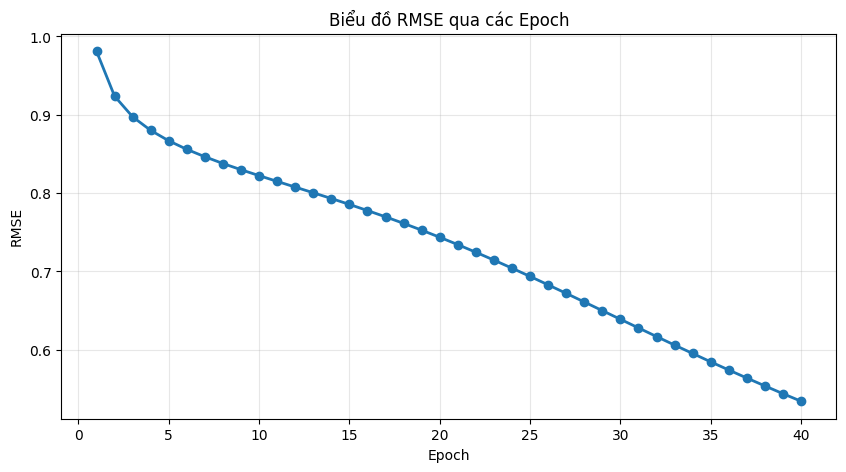

In [ ]:
import matplotlib.pyplot as plt

# Vẽ biểu đồ RMSE theo epoch
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(training_losses) + 1),
    training_losses,
    marker='o',
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Biểu đồ RMSE qua các Epoch")
plt.grid(True, alpha=0.3)

plt.show()

### 6.4. Hàm dự đoán rating

In [ ]:
def predict_rating(user_id, movie_id):
    """
    Dự đoán số sao user_id sẽ đánh giá movie_id
    """
    if user_id not in user_to_idx:
        return mu

    if movie_id not in movie_to_idx:
        return mu
    #Trả về index nội bộ trong bảng cf_data là cột user_idx
    u = user_to_idx[user_id]
    i = movie_to_idx[movie_id]

    pred = mu + bu[u] + bi[i] + np.dot(P[u], Q[i])

    # Giới hạn rating trong khoảng hợp lệ
    pred = np.clip(pred, 0.5, 5.0)

    return pred

### 6.5. Hàm gợi ý phim bằng MF-SGD

In [ ]:
def get_mf_recommendations(user_id, top_n=10):
    """
    Gợi ý phim cho user bằng Matrix Factorization học bằng SGD
    """
    if user_id not in user_to_idx:
        print(f"User {user_id} khong ton tai trong du lieu")
        return pd.DataFrame()

    # Các phim user đã đánh giá
    rated_movies = cf_data[cf_data['userId'] == user_id]['movieId'].tolist()

    recommendations = []

    for movie_id in movie_ids:
        if movie_id in rated_movies:
            continue

        pred_rating = predict_rating(user_id, movie_id)

        recommendations.append({
            'movieId': movie_id,
            'predicted_rating': pred_rating
        })

    recommendations = pd.DataFrame(recommendations)

    recommendations = recommendations.sort_values(
        'predicted_rating',
        ascending=False
    ).head(top_n)

    recommendations = recommendations.merge(
        movie_meta[['movieId', 'id', 'title']],
        on='movieId',
        how='left'
    )

    recommendations['rank'] = range(1, len(recommendations) + 1)

    return recommendations[['rank', 'movieId', 'id', 'title', 'predicted_rating']]

### 6.6 Test

In [ ]:
display(get_mf_recommendations(user_id=1, top_n=10))

,rank,movieId,id,title,predicted_rating
0,1,1204,947,Lawrence of Arabia,5.0
1,2,1028,433,Mary Poppins,5.0
2,3,56367,7326,Juno,5.0
3,4,910,239,Some Like It Hot,5.0
4,5,1233,387,Das Boot,5.0
5,6,588,812,Aladdin,5.0
6,7,5618,129,Spirited Away,5.0
7,8,3468,990,The Hustler,5.0
8,9,7090,79,Hero,5.0
9,10,1246,207,Dead Poets Society,5.0


## **7. Hybrid Recommendations**


### 7.1. Hybrid Function

In [ ]:
def normalize_series(series):
    series = pd.Series(series).astype(float)
    min_val = series.min()
    max_val = series.max()

    if pd.isna(min_val) or pd.isna(max_val):
        return pd.Series([0.0] * len(series), index=series.index)

    if max_val == min_val:
        return pd.Series([0.5] * len(series), index=series.index)

    return (series - min_val) / (max_val - min_val)


movie_meta = movie_meta.reset_index(drop=True)
movieid_to_content_idx = {
    movie_id: idx
    for idx, movie_id in enumerate(movie_meta['movieId'])
}


def build_user_content_profile(user_id, ratings_data=None, rating_threshold=3.5):
    """
    Realtime version:
    - Khong phu thuoc cung vao train_ratings.
    - Co the truyen ratings_data = ratings goc + rating moi.
    """
    if ratings_data is None:
        ratings_data = train_ratings

    user_liked = ratings_data[
        (ratings_data['userId'] == user_id) &
        (ratings_data['rating'] >= rating_threshold)
    ]

    if user_liked.empty:
        return None

    liked_indices = [
        movieid_to_content_idx[movie_id]
        for movie_id in user_liked['movieId'].values
        if movie_id in movieid_to_content_idx
    ]

    if len(liked_indices) == 0:
        return None

    return content_features[liked_indices].mean(axis=0)


def build_manual_popularity_lookup(ratings_data, smoothing=20):
    # Tinh popularity kiểu Bayesian để tránh ưu tiên quá mức phim có quá ít rating.
    if ratings_data is None or ratings_data.empty:
        return {}

    stats = ratings_data.groupby('movieId')['rating'].agg(['mean', 'count']).reset_index()
    global_mean = ratings_data['rating'].mean()
    stats['popularity_score'] = (
        (stats['count'] / (stats['count'] + smoothing)) * stats['mean'] +
        (smoothing / (stats['count'] + smoothing)) * global_mean
    )
    return stats.set_index('movieId')['popularity_score'].to_dict()


def get_hybrid_recommendations(
    user_id,
    top_n=10,
    alpha=0.6,
    popularity_weight=0.2,
    hybrid_weights=None,
    rating_threshold=3.5,
    ratings_data=None
):
    """
    Hybrid manual baseline:
    - CF score dung model MF da train offline.
    - CBF score cap nhat tu ratings_data hien tai.
    - Popularity score dung Bayesian popularity tinh tu ratings_data.
    - Mac dinh: 0.6 CF + 0.3 CBF + 0.1 popularity.
    """
    if ratings_data is None:
        ratings_data = train_ratings

    if user_id not in user_to_idx:
        print(f"User {user_id} khong ton tai trong tap train")
        return pd.DataFrame()

    if hybrid_weights is None:
        w_cf = alpha
        w_pop = popularity_weight
        w_cbf = 1 - w_cf - w_pop
    else:
        w_cf, w_cbf, w_pop = hybrid_weights

    if min(w_cf, w_cbf, w_pop) < 0:
        raise ValueError("Trong so hybrid phai khong am va tong khong vuot qua 1.")

    weight_sum = w_cf + w_cbf + w_pop
    if weight_sum == 0:
        raise ValueError("Tong trong so hybrid phai lon hon 0.")
    w_cf, w_cbf, w_pop = w_cf / weight_sum, w_cbf / weight_sum, w_pop / weight_sum

    rated_movies = set(
        ratings_data[ratings_data['userId'] == user_id]['movieId'].values
    )
    popularity_lookup = build_manual_popularity_lookup(ratings_data)

    user_profile = build_user_content_profile(
        user_id=user_id,
        ratings_data=ratings_data,
        rating_threshold=rating_threshold
    )

    rows = []

    for _, row in movie_meta.iterrows():
        movie_id = row['movieId']

        # Không gợi ý lại phim user đã đánh giá
        if movie_id in rated_movies:
            continue

        cf_score = predict_rating(user_id, movie_id)

        if user_profile is not None and movie_id in movieid_to_content_idx:
            movie_idx = movieid_to_content_idx[movie_id]
            cbf_score = cosine_similarity(
                user_profile.reshape(1, -1),
                content_features[movie_idx].reshape(1, -1)
            )[0][0]
        else:
            cbf_score = 0.0

        rows.append({
            'movieId': movie_id,
            'id': row['id'],
            'title': row['title'],
            'cf_score': cf_score,
            'cbf_score': cbf_score,
            'popularity_score': popularity_lookup.get(movie_id, 0.0)
        })

    recommendations = pd.DataFrame(rows)

    if recommendations.empty:
        return pd.DataFrame()

    recommendations['norm_cf'] = normalize_series(recommendations['cf_score'])
    recommendations['norm_cbf'] = normalize_series(recommendations['cbf_score'])
    recommendations['norm_popularity'] = normalize_series(recommendations['popularity_score'])

    recommendations['hybrid_score'] = (
        w_cf * recommendations['norm_cf'] +
        w_cbf * recommendations['norm_cbf'] +
        w_pop * recommendations['norm_popularity']
    )

    recommendations = recommendations.sort_values(
        'hybrid_score', ascending=False
    ).head(top_n).copy()

    recommendations['rank'] = range(1, len(recommendations) + 1)

    return recommendations[
        ['rank', 'movieId', 'id', 'title',
         'cf_score', 'cbf_score', 'popularity_score',
         'norm_cf', 'norm_cbf', 'norm_popularity', 'hybrid_score']
    ]


### 7.2 Lưu model và mapping cho Streamlit



In [ ]:
with open(MODELS_DIR / 'tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open(MODELS_DIR / 'content_features.pkl', 'wb') as f:
    pickle.dump(content_features, f)

svd_model = {
    'P': P,
    'Q': Q,
    'bu': bu,
    'bi': bi,
    'mu': mu,
    'user_to_idx': user_to_idx,
    'movie_to_idx': movie_to_idx,
    'idx_to_user': idx_to_user,
    'idx_to_movie': idx_to_movie,
    'num_factors': num_factors,
    'rating_min': 0.5,
    'rating_max': 5.0
}

with open(MODELS_DIR / 'svd_model.pkl', 'wb') as f:
    pickle.dump(svd_model, f)

mappings = {
    'movieid_to_content_idx': movieid_to_content_idx,
    'user_to_idx': user_to_idx,
    'movie_to_idx': movie_to_idx,
    'idx_to_user': idx_to_user,
    'idx_to_movie': idx_to_movie
}

with open(MODELS_DIR / 'mappings.pkl', 'wb') as f:
    pickle.dump(mappings, f)

print("Da luu model artifacts:")
for file_name in ['tfidf_vectorizer.pkl', 'content_features.pkl', 'svd_model.pkl', 'mappings.pkl']:
    print("   -", MODELS_DIR / file_name)


Da luu model artifacts:
   - /content/drive/MyDrive/RECOMMENDATION_SYSTEM/models/tfidf_vectorizer.pkl
   - /content/drive/MyDrive/RECOMMENDATION_SYSTEM/models/content_features.pkl
   - /content/drive/MyDrive/RECOMMENDATION_SYSTEM/models/svd_model.pkl
   - /content/drive/MyDrive/RECOMMENDATION_SYSTEM/models/mappings.pkl


### 7.3. Test realtime sau khi user đánh giá phim



In [ ]:
new_ratings = pd.DataFrame([
    {
        'userId': 1,
        'movieId': int(movie_meta.iloc[0]['movieId']),
        'rating': 5.0
    }
])

ratings_realtime = pd.concat(
    [train_ratings[['userId', 'movieId', 'rating']], new_ratings],
    ignore_index=True
)

realtime_recs = get_hybrid_recommendations(
    user_id=1,
    top_n=10,
    alpha=0.6,
    ratings_data=ratings_realtime
)

display(realtime_recs)


,rank,movieId,id,title,cf_score,cbf_score,popularity_score,norm_cf,norm_cbf,norm_popularity,hybrid_score
98,1,588,812,Aladdin,5.000000,0.214058,3.745233,1.000000,0.897425,0.856219,0.954850
179,2,1204,947,Lawrence of Arabia,5.000000,0.196016,4.080726,1.000000,0.817696,0.932918,0.938601
198,3,1262,5925,The Great Escape,4.889164,0.192802,3.980797,0.952958,0.803490,0.910073,0.903829
190,4,1233,387,Das Boot,5.000000,0.157823,3.991735,1.000000,0.648913,0.912574,0.885931
968,5,5618,129,Spirited Away,5.000000,0.155470,4.048092,1.000000,0.638512,0.925458,0.884099
192,6,1242,9665,Glory,4.996384,0.154451,3.934352,0.998465,0.634011,0.899455,0.879228
536,7,2989,699,For Your Eyes Only,4.847350,0.179341,3.577452,0.935211,0.744006,0.817862,0.866114
354,8,2011,165,Back to the Future Part II,4.692976,0.206652,3.453728,0.869690,0.864700,0.789577,0.860182
310,9,1884,1878,Fear and Loathing in Las Vegas,4.930506,0.152461,3.941028,0.970505,0.625216,0.900981,0.859966
1496,10,50068,1251,Letters from Iwo Jima,4.647032,0.207964,3.632960,0.850190,0.870497,0.830552,0.854318


### 7.4. Test Hybrid Recommendations

In [ ]:
hybrid_recs = get_hybrid_recommendations(
    user_id=1,
    alpha=0.6,
    top_n=10
)

display(hybrid_recs)


,rank,movieId,id,title,cf_score,cbf_score,popularity_score,norm_cf,norm_cbf,norm_popularity,hybrid_score
98,1,588,812,Aladdin,5.000000,0.213325,3.745227,1.000000,0.883481,0.856219,0.950666
179,2,1204,947,Lawrence of Arabia,5.000000,0.198417,4.080710,1.000000,0.818222,0.932916,0.938758
198,3,1262,5925,The Great Escape,4.889164,0.195825,3.980780,0.952958,0.806877,0.910070,0.904845
190,4,1233,387,Das Boot,5.000000,0.160042,3.991720,1.000000,0.650240,0.912571,0.886329
968,5,5618,129,Spirited Away,5.000000,0.155769,4.048083,1.000000,0.631537,0.925456,0.882007
192,6,1242,9665,Glory,4.996384,0.156442,3.934335,0.998465,0.634480,0.899452,0.879368
536,7,2989,699,For Your Eyes Only,4.847350,0.181337,3.577430,0.935211,0.743454,0.817858,0.865948
310,8,1884,1878,Fear and Loathing in Las Vegas,4.930506,0.153570,3.941013,0.970505,0.621910,0.900979,0.858974
354,9,2011,165,Back to the Future Part II,4.692976,0.205779,3.453718,0.869690,0.850449,0.789575,0.855906
1542,10,54190,4688,Across the Universe,4.832520,0.171732,3.776544,0.928917,0.701411,0.863378,0.854111


### 7.5. So sánh các phương pháp

In [ ]:
# So sánh 3 phương pháp
print("So sanh 3 phuong phap goi y:")
print("=" * 80)

movie_name = "Toy Story"
user_id = 1
top_n = 5

# 1. Content-Based Filtering
print(f"\n1 Content-Based Filtering dua tren phim '{movie_name}':")
cb_recs = get_content_based_recommendations(movie_name, top_n=top_n)

if not cb_recs.empty:
    display(cb_recs[['rank', 'title', 'similarity_score']])
else:
    print("Khong co ket qua Content-Based.")

# 2. Collaborative Filtering bằng Matrix Factorization
print(f"\n2 Collaborative Filtering bang MF-SGD cho User {user_id}:")
cf_recs = get_mf_recommendations(user_id, top_n=top_n)

if not cf_recs.empty:
    display(cf_recs[['rank', 'title', 'predicted_rating']])
else:
    print("Khong co ket qua Collaborative Filtering.")

# 3. Hybrid Recommendation theo user voi CF + CBF + popularity
print(f"\n3 Hybrid Recommendation cho User {user_id} voi CF + CBF + popularity:")
hybrid_recs = get_hybrid_recommendations(
    user_id=user_id,
    alpha=0.6,
    top_n=top_n
)

if not hybrid_recs.empty:
    display(hybrid_recs[['rank', 'title', 'cf_score', 'cbf_score', 'popularity_score', 'norm_cf', 'norm_cbf', 'norm_popularity', 'hybrid_score']])
else:
    print("Khong co ket qua Hybrid.")


So sanh 3 phuong phap goi y:

1 Content-Based Filtering dua tren phim 'Toy Story':


,rank,title,similarity_score
1422,1,The 40 Year Old Virgin,0.542716
1595,2,Factory Girl,0.277340
1431,3,The Man,0.186406
738,4,Firestarter,0.167828
1969,5,Larry Crowne,0.158697



2 Collaborative Filtering bang MF-SGD cho User 1:


,rank,title,predicted_rating
0,1,Lawrence of Arabia,5.0
1,2,Mary Poppins,5.0
2,3,Juno,5.0
3,4,Some Like It Hot,5.0
4,5,Das Boot,5.0



3 Hybrid Recommendation cho User 1 voi CF + CBF + popularity:


,rank,title,cf_score,cbf_score,popularity_score,norm_cf,norm_cbf,norm_popularity,hybrid_score
98,1,Aladdin,5.000000,0.213325,3.745227,1.000000,0.883481,0.856219,0.950666
179,2,Lawrence of Arabia,5.000000,0.198417,4.080710,1.000000,0.818222,0.932916,0.938758
198,3,The Great Escape,4.889164,0.195825,3.980780,0.952958,0.806877,0.910070,0.904845
190,4,Das Boot,5.000000,0.160042,3.991720,1.000000,0.650240,0.912571,0.886329
968,5,Spirited Away,5.000000,0.155769,4.048083,1.000000,0.631537,0.925456,0.882007


## **8. Improved Offline Training, Validation & Evaluation Pipeline**

Phần này là pipeline để so sánh các mô hình theo bài toán **top-K recommendation**.

- Tách `train / validation / test` để tune trên validation và chỉ báo cáo kết quả cuối trên test.
- Dùng chung metric `Precision@K`, `Recall@K`, `NDCG@K`.
- Bổ sung baseline mạnh hơn ngoài popularity.
- Tập trung vào ranking models trước khi quyết định model production.

In [ ]:
from itertools import product
from math import log2
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression

RANDOM_STATE = 42
K = 40
LIKED_THRESHOLD = 4.0
VALIDATION_SIZE = 0.2
TEST_SIZE = 0.2
EVAL_SAMPLE_SIZE = 100

development_ratings, test_ratings_v2 = train_test_split(
    final_ratings, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
train_ratings_v2, val_ratings_v2 = train_test_split(
    development_ratings, test_size=VALIDATION_SIZE, random_state=RANDOM_STATE
)


def temporal_leave_last_out_split(ratings_df):
    ordered = ratings_df.sort_values(["userId", "timestamp"])
    test_idx = ordered.groupby("userId").tail(1).index
    train_df = ordered.drop(index=test_idx).copy()
    test_df = ordered.loc[test_idx].copy()
    return train_df, test_df


temporal_train_ratings, temporal_test_ratings = temporal_leave_last_out_split(final_ratings)

print("Random split mới:")
print(f"   Train: {len(train_ratings_v2):,} ratings")
print(f"   Validation: {len(val_ratings_v2):,} ratings")
print(f"   Test: {len(test_ratings_v2):,} ratings")
print("Temporal split:")
print(f"   Train: {len(temporal_train_ratings):,} ratings")
print(f"   Test: {len(temporal_test_ratings):,} ratings")

Random split mới:
   Train: 25,904 ratings
   Validation: 6,476 ratings
   Test: 8,095 ratings
Temporal split:
   Train: 39,865 ratings
   Test: 610 ratings


### 8.1. Metric top-K dùng chung

In [ ]:
def precision_at_k(recommended, relevant):
    recommended = list(recommended)
    relevant = set(relevant)
    return len(set(recommended) & relevant) / len(recommended) if recommended else 0.0


def recall_at_k(recommended, relevant):
    relevant = set(relevant)
    return len(set(recommended) & relevant) / len(relevant) if relevant else 0.0


def ndcg_at_k(recommended, relevant):
    relevant = set(relevant)
    dcg = sum((1 / log2(idx + 2)) for idx, item in enumerate(recommended) if item in relevant)
    ideal_hits = min(len(relevant), len(recommended))
    idcg = sum((1 / log2(idx + 2)) for idx in range(ideal_hits))
    return dcg / idcg if idcg > 0 else 0.0


def get_eval_users(test_df, sample_size=EVAL_SAMPLE_SIZE, rating_threshold=LIKED_THRESHOLD, random_state=RANDOM_STATE):
    eligible_users = test_df[test_df["rating"] >= rating_threshold]["userId"].drop_duplicates()
    if sample_size is None or sample_size >= len(eligible_users):
        return eligible_users.tolist()
    return eligible_users.sample(n=sample_size, random_state=random_state).tolist()


def validate_recommendations(recommended, rated_movies, k=K):
    recommended = list(recommended)
    assert len(recommended) <= k
    assert len(recommended) == len(set(recommended))
    assert not (set(recommended) & set(rated_movies))


def evaluate_recommender(model_name, recommend_fn, train_df, test_df, eval_users, k=K, rating_threshold=LIKED_THRESHOLD):
    rows = []
    for user_id in eval_users:
        actual_liked = set(
            test_df[(test_df["userId"] == user_id) & (test_df["rating"] >= rating_threshold)]["movieId"].values
        )
        if not actual_liked:
            continue
        recommended = recommend_fn(user_id, k)
        if isinstance(recommended, pd.DataFrame):
            recommended = recommended["movieId"].tolist()
        recommended = list(recommended)[:k]
        if not recommended:
            continue
        rated_movies = train_df[train_df["userId"] == user_id]["movieId"].tolist()
        validate_recommendations(recommended, rated_movies, k=k)
        rows.append(
            {
                "model": model_name,
                "userId": user_id,
                "train_count": len(rated_movies),
                "precision_at_k": precision_at_k(recommended, actual_liked),
                "recall_at_k": recall_at_k(recommended, actual_liked),
                "ndcg_at_k": ndcg_at_k(recommended, actual_liked),
            }
        )
    detail_df = pd.DataFrame(rows)
    summary = {
        "model": model_name,
        "users_evaluated": len(detail_df),
        "precision_at_k": detail_df["precision_at_k"].mean() if not detail_df.empty else 0.0,
        "recall_at_k": detail_df["recall_at_k"].mean() if not detail_df.empty else 0.0,
        "ndcg_at_k": detail_df["ndcg_at_k"].mean() if not detail_df.empty else 0.0,
    }
    return summary, detail_df

### 8.2. Baseline mạnh hơn

In [ ]:
def build_popularity_table(ratings_df, min_ratings=20):
    stats = ratings_df.groupby("movieId").agg(
        avg_rating=("rating", "mean"), num_ratings=("rating", "count")
    ).reset_index()
    stats = stats[stats["num_ratings"] >= min_ratings].copy()
    stats["bayesian_popularity"] = (
        stats["avg_rating"] * stats["num_ratings"] + ratings_df["rating"].mean() * min_ratings
    ) / (stats["num_ratings"] + min_ratings)
    return stats.sort_values(["bayesian_popularity", "num_ratings"], ascending=False)


def get_popular_recommendations(popularity_table, ratings_df, user_id, top_n=10):
    rated_movies = set(ratings_df[ratings_df["userId"] == user_id]["movieId"].values)
    return [m for m in popularity_table["movieId"].tolist() if m not in rated_movies][:top_n]


def get_random_recommendations(ratings_df, user_id, candidate_movie_ids, top_n=10, random_state=RANDOM_STATE):
    rated_movies = set(ratings_df[ratings_df["userId"] == user_id]["movieId"].values)
    candidates = sorted(set(candidate_movie_ids) - rated_movies)
    if not candidates:
        return []
    rng = np.random.default_rng(random_state + int(user_id))
    return rng.choice(candidates, size=min(top_n, len(candidates)), replace=False).tolist()


def fit_bias_only_model(ratings_df, reg=10.0, n_iters=10):
    mu = ratings_df["rating"].mean()
    user_bias = pd.Series(0.0, index=ratings_df["userId"].unique())
    item_bias = pd.Series(0.0, index=ratings_df["movieId"].unique())
    for _ in range(n_iters):
        residual_u = ratings_df.assign(
            resid=ratings_df["rating"] - mu - ratings_df["movieId"].map(item_bias).fillna(0.0)
        )
        user_bias = residual_u.groupby("userId")["resid"].sum() / (
            reg + residual_u.groupby("userId").size()
        )
        residual_i = ratings_df.assign(
            resid=ratings_df["rating"] - mu - ratings_df["userId"].map(user_bias).fillna(0.0)
        )
        item_bias = residual_i.groupby("movieId")["resid"].sum() / (
            reg + residual_i.groupby("movieId").size()
        )
    return {"mu": mu, "user_bias": user_bias.to_dict(), "item_bias": item_bias.to_dict()}


def get_bias_only_recommendations(model, ratings_df, user_id, candidate_movie_ids, top_n=10):
    rated_movies = set(ratings_df[ratings_df["userId"] == user_id]["movieId"].values)
    bu = model["user_bias"].get(user_id, 0.0)
    rows = [
        (movie_id, model["mu"] + bu + model["item_bias"].get(movie_id, 0.0))
        for movie_id in candidate_movie_ids
        if movie_id not in rated_movies
    ]
    return [movie_id for movie_id, _ in sorted(rows, key=lambda x: x[1], reverse=True)[:top_n]]


def build_user_item_matrix(ratings_df, threshold=LIKED_THRESHOLD):
    implicit_df = ratings_df.copy()
    implicit_df["interaction"] = (implicit_df["rating"] >= threshold).astype(float)
    users = sorted(implicit_df["userId"].unique())
    movies = sorted(implicit_df["movieId"].unique())
    u2i = {u: i for i, u in enumerate(users)}
    m2i = {m: i for i, m in enumerate(movies)}
    matrix = np.zeros((len(users), len(movies)), dtype=np.float32)
    for row in implicit_df.itertuples(index=False):
        matrix[u2i[row.userId], m2i[row.movieId]] = row.interaction
    return matrix, u2i, m2i, {i: m for m, i in m2i.items()}


def fit_item_knn(ratings_df):
    matrix, u2i, m2i, i2m = build_user_item_matrix(ratings_df)
    sim = cosine_similarity(matrix.T)
    np.fill_diagonal(sim, 0.0)
    return {"matrix": matrix, "user_to_idx": u2i, "movie_to_idx": m2i, "idx_to_movie": i2m, "similarity": sim}


def get_item_knn_recommendations(model, ratings_df, user_id, top_n=10):
    if user_id not in model["user_to_idx"]:
        return []
    u = model["user_to_idx"][user_id]
    scores = model["matrix"][u].dot(model["similarity"])
    rated_movies = set(ratings_df[ratings_df["userId"] == user_id]["movieId"].values)
    rows = [
        (model["idx_to_movie"][idx], score)
        for idx, score in enumerate(scores)
        if model["idx_to_movie"][idx] not in rated_movies
    ]
    return [movie_id for movie_id, _ in sorted(rows, key=lambda x: x[1], reverse=True)[:top_n]]


def fit_user_knn(ratings_df):
    matrix, u2i, m2i, i2m = build_user_item_matrix(ratings_df)
    sim = cosine_similarity(matrix)
    np.fill_diagonal(sim, 0.0)
    return {"matrix": matrix, "user_to_idx": u2i, "movie_to_idx": m2i, "idx_to_movie": i2m, "similarity": sim}


def get_user_knn_recommendations(model, ratings_df, user_id, top_n=10):
    if user_id not in model["user_to_idx"]:
        return []
    u = model["user_to_idx"][user_id]
    scores = model["similarity"][u].dot(model["matrix"])
    rated_movies = set(ratings_df[ratings_df["userId"] == user_id]["movieId"].values)
    rows = [
        (model["idx_to_movie"][idx], score)
        for idx, score in enumerate(scores)
        if model["idx_to_movie"][idx] not in rated_movies
    ]
    return [movie_id for movie_id, _ in sorted(rows, key=lambda x: x[1], reverse=True)[:top_n]]


popularity_table_train = build_popularity_table(train_ratings_v2)
popularity_table_dev = build_popularity_table(development_ratings)
bias_only_train = fit_bias_only_model(train_ratings_v2)
bias_only_dev = fit_bias_only_model(development_ratings)
item_knn_train = fit_item_knn(train_ratings_v2)
item_knn_dev = fit_item_knn(development_ratings)
user_knn_train = fit_user_knn(train_ratings_v2)
user_knn_dev = fit_user_knn(development_ratings)
all_movie_ids = movie_meta["movieId"].tolist()

### 8.3. Matrix Factorization tối ưu theo ranking

In [ ]:
def prepare_cf_data(ratings_df):
    cf_df = ratings_df[["userId", "movieId", "rating"]].copy()
    users = cf_df["userId"].unique()
    movies = cf_df["movieId"].unique()
    u2i = {user_id: idx for idx, user_id in enumerate(users)}
    m2i = {movie_id: idx for idx, movie_id in enumerate(movies)}
    i2u = {idx: user_id for user_id, idx in u2i.items()}
    i2m = {idx: movie_id for movie_id, idx in m2i.items()}
    cf_df["user_idx"] = cf_df["userId"].map(u2i)
    cf_df["movie_idx"] = cf_df["movieId"].map(m2i)
    return cf_df, u2i, m2i, i2u, i2m


def train_mf_sgd(ratings_df, num_factors=40, learning_rate=0.005, reg=0.01, epochs=30, random_state=RANDOM_STATE):
    cf_df, u2i, m2i, i2u, i2m = prepare_cf_data(ratings_df)
    rng = np.random.default_rng(random_state)
    P_local = rng.normal(0, 0.1, size=(len(u2i), num_factors))
    Q_local = rng.normal(0, 0.1, size=(len(m2i), num_factors))
    bu_local = np.zeros(len(u2i))
    bi_local = np.zeros(len(m2i))
    mu_local = cf_df["rating"].mean()
    training_rmse = []
    for epoch in range(epochs):
        shuffled = cf_df.sample(frac=1, random_state=random_state + epoch)
        total_squared_error = 0.0
        for row in shuffled.itertuples(index=False):
            u, i, r_ui = row.user_idx, row.movie_idx, row.rating
            pred = mu_local + bu_local[u] + bi_local[i] + np.dot(P_local[u], Q_local[i])
            err = r_ui - pred
            old_pu = P_local[u].copy()
            old_qi = Q_local[i].copy()
            bu_local[u] += learning_rate * (err - reg * bu_local[u])
            bi_local[i] += learning_rate * (err - reg * bi_local[i])
            P_local[u] += learning_rate * (err * old_qi - reg * old_pu)
            Q_local[i] += learning_rate * (err * old_pu - reg * old_qi)
            total_squared_error += err ** 2
        training_rmse.append(float(np.sqrt(total_squared_error / len(cf_df))))
    return {
        "model_type": "mf_explicit",
        "P": P_local,
        "Q": Q_local,
        "bu": bu_local,
        "bi": bi_local,
        "mu": mu_local,
        "user_to_idx": u2i,
        "movie_to_idx": m2i,
        "idx_to_user": i2u,
        "idx_to_movie": i2m,
        "num_factors": num_factors,
        "rating_min": 0.5,
        "rating_max": 5.0,
        "training_rmse": training_rmse,
        "hyperparams": {
            "num_factors": num_factors,
            "learning_rate": learning_rate,
            "reg": reg,
            "epochs": epochs,
        },
    }


def predict_rating_from_model(model, user_id, movie_id):
    if user_id not in model["user_to_idx"] or movie_id not in model["movie_to_idx"]:
        return model.get("mu", 0.0)
    u = model["user_to_idx"][user_id]
    i = model["movie_to_idx"][movie_id]
    bu = model.get("bu")
    bi = model.get("bi")
    pred = model.get("mu", 0.0)
    if bu is not None:
        pred += bu[u]
    if bi is not None:
        pred += bi[i]
    pred += np.dot(model["P"][u], model["Q"][i])
    return float(np.clip(pred, model.get("rating_min", -np.inf), model.get("rating_max", np.inf)))


def get_model_recommendations(model, ratings_df, user_id, top_n=10):
    if user_id not in model["user_to_idx"]:
        return pd.DataFrame(columns=["movieId", "score"])
    rated_movies = set(ratings_df[ratings_df["userId"] == user_id]["movieId"].values)
    rows = [
        {"movieId": movie_id, "score": predict_rating_from_model(model, user_id, movie_id)}
        for movie_id in model["movie_to_idx"].keys()
        if movie_id not in rated_movies
    ]
    return pd.DataFrame(rows).sort_values("score", ascending=False).head(top_n)


mf_param_grid = [
    {"num_factors": 20, "learning_rate": 0.005, "reg": 0.01, "epochs": 20},
    {"num_factors": 40, "learning_rate": 0.005, "reg": 0.01, "epochs": 25},
    {"num_factors": 60, "learning_rate": 0.005, "reg": 0.02, "epochs": 25},
]
val_eval_users = get_eval_users(val_ratings_v2)
trained_mf_models, mf_tuning_rows = [], []
for params in mf_param_grid:
    candidate = train_mf_sgd(train_ratings_v2, **params)
    summary, _ = evaluate_recommender(
        "MF candidate",
        lambda user_id, k, model=candidate: get_model_recommendations(model, train_ratings_v2, user_id, k),
        train_ratings_v2,
        val_ratings_v2,
        val_eval_users,
        k=K,
    )
    trained_mf_models.append(candidate)
    mf_tuning_rows.append({**params, **summary})
mf_tuning_results = pd.DataFrame(mf_tuning_rows).sort_values(
    ["recall_at_k", "ndcg_at_k", "precision_at_k"], ascending=False
).reset_index(drop=True)
display(mf_tuning_results)
best_mf_params = mf_tuning_results.iloc[0][["num_factors", "learning_rate", "reg", "epochs"]].to_dict()
best_mf_params["num_factors"] = int(best_mf_params["num_factors"])
best_mf_params["epochs"] = int(best_mf_params["epochs"])
best_mf_train_model = train_mf_sgd(train_ratings_v2, **best_mf_params)
final_mf_model = train_mf_sgd(development_ratings, **best_mf_params)

,num_factors,learning_rate,reg,epochs,model,users_evaluated,precision_at_k,recall_at_k,ndcg_at_k
0,20,0.005,0.01,20,MF candidate,100,0.03175,0.268006,0.146001
1,60,0.005,0.02,25,MF candidate,100,0.03325,0.261341,0.143500
2,40,0.005,0.01,25,MF candidate,100,0.03000,0.230091,0.144931


### 8.4. BPR-MF và ALS implicit

In [ ]:
def prepare_implicit_data(ratings_df, threshold=LIKED_THRESHOLD):
    positives = ratings_df[ratings_df["rating"] >= threshold][["userId", "movieId"]].drop_duplicates()
    users = positives["userId"].unique()
    movies = ratings_df["movieId"].unique()
    u2i = {u: idx for idx, u in enumerate(users)}
    m2i = {m: idx for idx, m in enumerate(movies)}
    i2m = {idx: m for m, idx in m2i.items()}
    user_positives = {
        u2i[u]: set(group["movieId"].map(m2i))
        for u, group in positives.groupby("userId")
        if u in u2i
    }
    return positives, u2i, m2i, i2m, user_positives


def train_bpr_mf(ratings_df, num_factors=40, learning_rate=0.03, reg=0.002, epochs=20, random_state=RANDOM_STATE):
    positives, u2i, m2i, i2m, user_positives = prepare_implicit_data(ratings_df)
    rng = np.random.default_rng(random_state)
    P_local = rng.normal(0, 0.1, size=(len(u2i), num_factors))
    Q_local = rng.normal(0, 0.1, size=(len(m2i), num_factors))
    all_items = np.arange(len(m2i))
    positive_pairs = [(u2i[row.userId], m2i[row.movieId]) for row in positives.itertuples(index=False)]
    for _ in range(epochs):
        for _ in range(len(positive_pairs)):
            u, i = positive_pairs[rng.integers(len(positive_pairs))]
            j = int(rng.choice(all_items))
            while j in user_positives[u]:
                j = int(rng.choice(all_items))
            x_uij = np.dot(P_local[u], Q_local[i] - Q_local[j])
            sigmoid = 1.0 / (1.0 + np.exp(x_uij))
            pu_old = P_local[u].copy()
            qi_old = Q_local[i].copy()
            qj_old = Q_local[j].copy()
            P_local[u] += learning_rate * (sigmoid * (qi_old - qj_old) - reg * pu_old)
            Q_local[i] += learning_rate * (sigmoid * pu_old - reg * qi_old)
            Q_local[j] += learning_rate * (-sigmoid * pu_old - reg * qj_old)
    return {
        "model_type": "bpr_mf",
        "P": P_local,
        "Q": Q_local,
        "user_to_idx": u2i,
        "movie_to_idx": m2i,
        "idx_to_movie": i2m,
        "mu": 0.0,
        "rating_min": -np.inf,
        "rating_max": np.inf,
        "hyperparams": {
            "num_factors": num_factors,
            "learning_rate": learning_rate,
            "reg": reg,
            "epochs": epochs,
        },
    }


def train_implicit_als(ratings_df, num_factors=20, alpha=10.0, reg=0.1, epochs=5, random_state=RANDOM_STATE):
    _, u2i, m2i, i2m, _ = prepare_implicit_data(ratings_df)
    rng = np.random.default_rng(random_state)
    R = np.zeros((len(u2i), len(m2i)), dtype=np.float32)
    for row in ratings_df.itertuples(index=False):
        if row.userId in u2i and row.movieId in m2i and row.rating >= LIKED_THRESHOLD:
            R[u2i[row.userId], m2i[row.movieId]] = 1.0
    X = rng.normal(0, 0.1, size=(len(u2i), num_factors))
    Y = rng.normal(0, 0.1, size=(len(m2i), num_factors))
    eye = np.eye(num_factors)
    user_positive_items = {u: np.flatnonzero(R[u]) for u in range(R.shape[0])}
    item_positive_users = {i: np.flatnonzero(R[:, i]) for i in range(R.shape[1])}
    for _ in range(epochs):
        YTY = Y.T @ Y
        for u in range(len(u2i)):
            items = user_positive_items[u]
            if len(items) == 0:
                continue
            Y_u = Y[items]
            A = YTY + alpha * (Y_u.T @ Y_u) + reg * eye
            b = (1.0 + alpha) * Y_u.sum(axis=0)
            X[u] = np.linalg.solve(A, b)
        XTX = X.T @ X
        for i in range(len(m2i)):
            users = item_positive_users[i]
            if len(users) == 0:
                continue
            X_i = X[users]
            A = XTX + alpha * (X_i.T @ X_i) + reg * eye
            b = (1.0 + alpha) * X_i.sum(axis=0)
            Y[i] = np.linalg.solve(A, b)
    return {
        "model_type": "als_implicit",
        "P": X,
        "Q": Y,
        "user_to_idx": u2i,
        "movie_to_idx": m2i,
        "idx_to_movie": i2m,
        "mu": 0.0,
        "rating_min": -np.inf,
        "rating_max": np.inf,
        "hyperparams": {"num_factors": num_factors, "alpha": alpha, "reg": reg, "epochs": epochs},
    }

# Mở rộng lưới tham số cho BPR
bpr_param_grid = [
    {"num_factors": 20, "learning_rate": 0.01, "reg": 0.001, "epochs": 15},
    {"num_factors": 40, "learning_rate": 0.03, "reg": 0.002, "epochs": 20},
    {"num_factors": 60, "learning_rate": 0.05, "reg": 0.005, "epochs": 25},
    {"num_factors": 100, "learning_rate": 0.01, "reg": 0.01, "epochs": 20}
]
bpr_rows, trained_bpr_models = [], []
for params in bpr_param_grid:
    candidate = train_bpr_mf(train_ratings_v2, **params)
    summary, _ = evaluate_recommender(
        "BPR candidate",
        lambda user_id, k, model=candidate: get_model_recommendations(model, train_ratings_v2, user_id, k),
        train_ratings_v2,
        val_ratings_v2,
        val_eval_users,
        k=K,
    )
    bpr_rows.append({**params, **summary})
    trained_bpr_models.append(candidate)
bpr_tuning_results = pd.DataFrame(bpr_rows).sort_values(
    ["recall_at_k", "ndcg_at_k", "precision_at_k"], ascending=False
).reset_index(drop=True)
display(bpr_tuning_results)
best_bpr_params = bpr_tuning_results.iloc[0][["num_factors", "learning_rate", "reg", "epochs"]].to_dict()
best_bpr_params["num_factors"] = int(best_bpr_params["num_factors"])
best_bpr_params["epochs" ] = int(best_bpr_params["epochs"])
best_bpr_train_model = train_bpr_mf(train_ratings_v2, **best_bpr_params)
final_bpr_model = train_bpr_mf(development_ratings, **best_bpr_params)

# Mở rộng lưới tham số cho ALS
als_param_grid = [
    {"num_factors": 20, "alpha": 10.0, "reg": 0.1, "epochs": 5},
    {"num_factors": 40, "alpha": 20.0, "reg": 0.01, "epochs": 10},
    {"num_factors": 60, "alpha": 40.0, "reg": 0.1, "epochs": 10}
]
als_rows, trained_als_models = [], []
for params in als_param_grid:
    candidate = train_implicit_als(train_ratings_v2, **params)
    summary, _ = evaluate_recommender(
        "ALS candidate",
        lambda user_id, k, model=candidate: get_model_recommendations(model, train_ratings_v2, user_id, k),
        train_ratings_v2,
        val_ratings_v2,
        val_eval_users,
        k=K,
    )
    als_rows.append({**params, **summary})
    trained_als_models.append(candidate)
als_tuning_results = pd.DataFrame(als_rows).sort_values(
    ["recall_at_k", "ndcg_at_k", "precision_at_k"], ascending=False
).reset_index(drop=True)
display(als_tuning_results)
best_als_params = als_tuning_results.iloc[0][["num_factors", "alpha", "reg", "epochs"]].to_dict()
final_als_model = train_implicit_als(development_ratings, **best_als_params)

,num_factors,learning_rate,reg,epochs,model,users_evaluated,precision_at_k,recall_at_k,ndcg_at_k
0,60,0.05,0.005,25,BPR candidate,100,0.05425,0.412391,0.235377
1,40,0.03,0.002,20,BPR candidate,100,0.05300,0.405693,0.226996
2,100,0.01,0.010,20,BPR candidate,100,0.04250,0.275097,0.176218
3,20,0.01,0.001,15,BPR candidate,100,0.01350,0.093324,0.058353


,num_factors,alpha,reg,epochs,model,users_evaluated,precision_at_k,recall_at_k,ndcg_at_k
0,20,10.0,0.10,5,ALS candidate,100,0.05450,0.442288,0.253557
1,40,20.0,0.01,10,ALS candidate,100,0.04175,0.339640,0.185462
2,60,40.0,0.10,10,ALS candidate,100,0.03150,0.284550,0.157562


### 8.5. Tune content dimensions theo metric ranking

In [ ]:
def build_content_features_for_dim(n_components):
    model = TruncatedSVD(n_components=min(n_components, tfidf_matrix.shape[1] - 1), random_state=RANDOM_STATE)
    return model.fit_transform(tfidf_matrix), float(model.explained_variance_ratio_.sum())


def build_weighted_profile(user_id, ratings_df, content_matrix, positive_threshold=3.5, negative_threshold=2.5, negative_weight=0.25):
    user_rows = ratings_df[ratings_df["userId"] == user_id]
    positive_rows = user_rows[user_rows["rating"] >= positive_threshold]
    negative_rows = user_rows[user_rows["rating"] <= negative_threshold]
    positive_valid = positive_rows[positive_rows["movieId"].isin(movieid_to_content_idx)]
    negative_valid = negative_rows[negative_rows["movieId"].isin(movieid_to_content_idx)]
    if positive_valid.empty:
        return None
    positive_indices = [movieid_to_content_idx[mid] for mid in positive_valid["movieId"].values]
    positive_profile = np.average(content_matrix[positive_indices], axis=0, weights=positive_valid["rating"].values)
    if negative_valid.empty:
        return positive_profile
    negative_indices = [movieid_to_content_idx[mid] for mid in negative_valid["movieId"].values]
    negative_profile = np.average(content_matrix[negative_indices], axis=0, weights=(5.5 - negative_valid["rating"]).values)
    return positive_profile - negative_weight * negative_profile


def get_cbf_recommendations_with_matrix(user_id, ratings_df, content_matrix, top_n=10):
    profile = build_weighted_profile(user_id, ratings_df, content_matrix)
    rated_movies = set(ratings_df[ratings_df["userId"] == user_id]["movieId"].values)
    if profile is None:
        return []
    scores = cosine_similarity(profile.reshape(1, -1), content_matrix).ravel()
    rows = [(mid, scores[movieid_to_content_idx[mid]]) for mid in movie_meta["movieId"].tolist() if mid not in rated_movies]
    return [movie_id for movie_id, _ in sorted(rows, key=lambda x: x[1], reverse=True)[:top_n]]


content_dim_grid = [50, 100, 200, 300, 500]
content_dim_rows, content_feature_candidates = [], {}
for dim in content_dim_grid:
    features_dim, explained = build_content_features_for_dim(dim)
    summary, _ = evaluate_recommender(
        f"CBF dim={dim}",
        lambda user_id, k, matrix=features_dim: get_cbf_recommendations_with_matrix(user_id, train_ratings_v2, matrix, k),
        train_ratings_v2,
        val_ratings_v2,
        val_eval_users,
        k=K,
    )
    content_dim_rows.append({"n_components": dim, "explained_variance": explained, **summary})
    content_feature_candidates[dim] = features_dim
content_dim_results = pd.DataFrame(content_dim_rows).sort_values(
    ["recall_at_k", "ndcg_at_k", "precision_at_k"], ascending=False
).reset_index(drop=True)
display(content_dim_results)
best_content_dim = int(content_dim_results.iloc[0]["n_components"])
content_features_v2 = content_feature_candidates[best_content_dim]
print("Best content dimension:", best_content_dim)

,n_components,explained_variance,model,users_evaluated,precision_at_k,recall_at_k,ndcg_at_k
0,500,0.580958,CBF dim=500,100,0.01125,0.080564,0.053101
1,300,0.422763,CBF dim=300,100,0.01100,0.079808,0.047563
2,200,0.321933,CBF dim=200,100,0.01050,0.077259,0.042741
3,100,0.197352,CBF dim=100,100,0.00850,0.075683,0.040291
4,50,0.118735,CBF dim=50,100,0.00775,0.068149,0.029023


Best content dimension: 500


### 8.6. Hybrid có kiểm soát và learned blender

In [ ]:
def normalize_scores(series, method="minmax"):
    values = pd.Series(series).astype(float)
    if method == "minmax":
        min_val, max_val = values.min(), values.max()
        return pd.Series(0.5, index=values.index) if max_val == min_val else (values - min_val) / (max_val - min_val)
    if method == "zscore":
        std = values.std(ddof=0)
        return pd.Series(0.0, index=values.index) if std == 0 else (values - values.mean()) / std
    if method == "rank":
        return values.rank(method="average", pct=True)
    raise ValueError(f"Unknown normalization method: {method}")


def build_candidate_frame(user_id, ranking_model, ratings_df, popularity_table, content_matrix=content_features_v2):
    rated_movies = set(ratings_df[ratings_df["userId"] == user_id]["movieId"].values)
    candidate_meta = movie_meta[~movie_meta["movieId"].isin(rated_movies)][["movieId", "id", "title"]].copy()
    candidate_meta["cf_score"] = [predict_rating_from_model(ranking_model, user_id, mid) for mid in candidate_meta["movieId"]]
    profile = build_weighted_profile(user_id, ratings_df, content_matrix)
    if profile is not None:
        all_cbf = cosine_similarity(profile.reshape(1, -1), content_matrix).ravel()
        candidate_meta["cbf_score"] = [all_cbf[movieid_to_content_idx[mid]] for mid in candidate_meta["movieId"]]
    else:
        candidate_meta["cbf_score"] = 0.0
    popularity_lookup = popularity_table.set_index("movieId")["bayesian_popularity"].to_dict()
    candidate_meta["popularity_score"] = candidate_meta["movieId"].map(popularity_lookup).fillna(0.0)
    return candidate_meta


def score_hybrid_candidates(candidates, weights=(0.5, 0.3, 0.2), normalization="rank", top_n=10):
    scored = candidates.copy()
    scored["norm_cf"] = normalize_scores(scored["cf_score"], normalization)
    scored["norm_cbf"] = normalize_scores(scored["cbf_score"], normalization)
    scored["norm_popularity"] = normalize_scores(scored["popularity_score"], normalization)
    w_cf, w_cbf, w_pop = weights
    scored["hybrid_score"] = (
        w_cf * scored["norm_cf"] +
        w_cbf * scored["norm_cbf"] +
        w_pop * scored["norm_popularity"]
    )
    return scored.sort_values("hybrid_score", ascending=False).head(top_n)


def get_hybrid_recommendations_v2(user_id, ranking_model, ratings_df, popularity_table, top_n=10, weights=(0.5, 0.3, 0.2), normalization="rank"):
    return score_hybrid_candidates(
        build_candidate_frame(user_id, ranking_model, ratings_df, popularity_table),
        weights,
        normalization,
        top_n,
    )


ranking_model_candidates = {
    "MF tuned": best_mf_train_model,
    "BPR tuned": best_bpr_train_model,
    "ALS implicit": trained_als_models[0],
}
best_validation_ranking_name = max(
    [
        ("MF tuned", mf_tuning_results.iloc[0]["recall_at_k"]),
        ("BPR tuned", bpr_tuning_results.iloc[0]["recall_at_k"]),
        ("ALS implicit", als_tuning_results.iloc[0]["recall_at_k"]),
    ],
    key=lambda x: x[1],
)[0]
best_validation_ranking_model = ranking_model_candidates[best_validation_ranking_name]

weight_grid = [(0.6, 0.4, 0.0), (0.6, 0.0, 0.4), (0.5, 0.3, 0.2), (0.4, 0.2, 0.4), (0.3, 0.3, 0.4)]
normalization_grid = ["minmax", "rank"]
validation_candidate_cache = {
    u: build_candidate_frame(u, best_validation_ranking_model, train_ratings_v2, popularity_table_train)
    for u in val_eval_users
}
hybrid_rows = []
for normalization in normalization_grid:
    for weights in weight_grid:
        summary, _ = evaluate_recommender(
            "Hybrid candidate",
            lambda user_id, k, w=weights, n=normalization: score_hybrid_candidates(validation_candidate_cache[user_id], w, n, k),
            train_ratings_v2,
            val_ratings_v2,
            val_eval_users,
            k=K,
        )
        hybrid_rows.append({"weights": weights, "normalization": normalization, **summary})
hybrid_tuning_results = pd.DataFrame(hybrid_rows).sort_values(
    ["recall_at_k", "ndcg_at_k", "precision_at_k"], ascending=False
).reset_index(drop=True)
display(hybrid_tuning_results)
best_hybrid_weights = tuple(hybrid_tuning_results.iloc[0]["weights"])
best_hybrid_normalization = hybrid_tuning_results.iloc[0]["normalization"]

# Normalize the candidate frames in the cache for the blender
normalization_method_for_blender = best_hybrid_normalization
for user_id in val_eval_users:
    df_to_normalize = validation_candidate_cache[user_id]
    df_to_normalize['norm_cf'] = normalize_scores(df_to_normalize['cf_score'], normalization_method_for_blender)
    df_to_normalize['norm_cbf'] = normalize_scores(df_to_normalize['cbf_score'], normalization_method_for_blender)
    df_to_normalize['norm_popularity'] = normalize_scores(df_to_normalize['popularity_score'], normalization_method_for_blender)
    validation_candidate_cache[user_id] = df_to_normalize # Update the cache

def build_blender_training_frame(candidate_cache, test_df, eval_users):
    """Create supervised rows for the learned hybrid blender.

    Each row is a candidate movie generated by CF + CBF + popularity features.
    The target is 1 when the user liked that movie in the validation holdout.
    """
    frames = []
    for user_id in eval_users:
        frame = candidate_cache[user_id].copy()
        relevant = set(test_df[(test_df["userId"] == user_id) & (test_df["rating"] >= LIKED_THRESHOLD)]["movieId"].values)
        frame["label"] = frame["movieId"].isin(relevant).astype(int)
        frame["userId"] = user_id
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)


# Learned blender: learn how to combine CF, CBF, and popularity instead of using fixed weights.
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

blender_train = build_blender_training_frame(validation_candidate_cache, val_ratings_v2, val_eval_users)

# Add normalization to blender_train before fitting the blender
normalization_method = best_hybrid_normalization
blender_train['norm_cf'] = normalize_scores(blender_train['cf_score'], normalization_method)
blender_train['norm_cbf'] = normalize_scores(blender_train['cbf_score'], normalization_method)
blender_train['norm_popularity'] = normalize_scores(blender_train['popularity_score'], normalization_method)

blender_features = ["norm_cf", "norm_cbf", "norm_popularity"]
blender_label_summary = blender_train["label"].value_counts().rename_axis("label").reset_index(name="rows")
display(blender_label_summary)

if blender_train["label"].nunique() < 2:
    raise ValueError("Learned blender needs both positive and negative labels in the validation set.")

logistic_blender = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight="balanced", max_iter=500, random_state=RANDOM_STATE),
)
logistic_blender.fit(blender_train[blender_features], blender_train["label"])

blender_coefficients = pd.DataFrame(
    {
        "feature": blender_features,
        "coefficient": logistic_blender.named_steps["logisticregression"].coef_[0],
    }
).sort_values("coefficient", ascending=False)
display(blender_coefficients)


def score_blended_candidates(candidates, top_n=10):
    scored = candidates.copy()
    scored["blend_score"] = logistic_blender.predict_proba(scored[blender_features])[:, 1]
    scored["hybrid_score"] = scored["blend_score"]
    scored = scored.sort_values("blend_score", ascending=False).head(top_n).copy()
    scored["rank"] = range(1, len(scored) + 1)
    return scored


blender_validation_summary, blender_validation_detail = evaluate_recommender(
    "Logistic learned blender",
    lambda user_id, k: score_blended_candidates(validation_candidate_cache[user_id], k),
    train_ratings_v2,
    val_ratings_v2,
    val_eval_users,
    k=K,
)
display(pd.DataFrame([blender_validation_summary]))


def get_blended_recommendations(user_id, ranking_model, ratings_df, popularity_table, top_n=10):
    candidates = build_candidate_frame(user_id, ranking_model, ratings_df, popularity_table)
    return score_blended_candidates(candidates, top_n)


,weights,normalization,model,users_evaluated,precision_at_k,recall_at_k,ndcg_at_k
0,"(0.4, 0.2, 0.4)",minmax,Hybrid candidate,100,0.06075,0.472567,0.282318
1,"(0.6, 0.0, 0.4)",minmax,Hybrid candidate,100,0.05875,0.466050,0.266290
2,"(0.5, 0.3, 0.2)",minmax,Hybrid candidate,100,0.05850,0.457334,0.274310
3,"(0.3, 0.3, 0.4)",minmax,Hybrid candidate,100,0.05775,0.449335,0.266711
4,"(0.6, 0.0, 0.4)",rank,Hybrid candidate,100,0.05725,0.440441,0.265400
5,"(0.6, 0.4, 0.0)",minmax,Hybrid candidate,100,0.05375,0.403092,0.247437
6,"(0.4, 0.2, 0.4)",rank,Hybrid candidate,100,0.04800,0.356990,0.216605
7,"(0.5, 0.3, 0.2)",rank,Hybrid candidate,100,0.04575,0.314033,0.199488
8,"(0.3, 0.3, 0.4)",rank,Hybrid candidate,100,0.04400,0.300225,0.194183
9,"(0.6, 0.4, 0.0)",rank,Hybrid candidate,100,0.03875,0.275936,0.174119


,label,rows
0,0,228925
1,1,622


,feature,coefficient
0,norm_cf,0.677697
2,norm_popularity,0.676581
1,norm_cbf,0.585420


,model,users_evaluated,precision_at_k,recall_at_k,ndcg_at_k
0,Logistic learned blender,100,0.055,0.423894,0.250343


### 8.7. Benchmark cuối cùng trên test set

In [ ]:
test_eval_users = get_eval_users(test_ratings_v2)
final_ranking_models = {"MF tuned": final_mf_model, "BPR tuned": final_bpr_model, "ALS implicit": final_als_model}
final_best_ranking_model = final_ranking_models[best_validation_ranking_name]

def get_blended_recommendations(user_id, ranking_model, ratings_df, popularity_table, top_n=10):
    candidates = build_candidate_frame(user_id, ranking_model, ratings_df, popularity_table)

    # Apply normalization to the candidate scores as expected by the trained blender
    normalization_method = best_hybrid_normalization # Use the determined normalization method from tuning
    candidates['norm_cf'] = normalize_scores(candidates['cf_score'], normalization_method)
    candidates['norm_cbf'] = normalize_scores(candidates['cbf_score'], normalization_method)
    candidates['norm_popularity'] = normalize_scores(candidates['popularity_score'], normalization_method)

    return score_blended_candidates(candidates, top_n)

benchmark_specs = [
    ("Random baseline", lambda user_id, k: get_random_recommendations(development_ratings, user_id, all_movie_ids, k)),
    ("Popular baseline", lambda user_id, k: get_popular_recommendations(popularity_table_dev, development_ratings, user_id, k)),
    ("Bias-only baseline", lambda user_id, k: get_bias_only_recommendations(bias_only_dev, development_ratings, user_id, all_movie_ids, k)),
    ("Item-KNN baseline", lambda user_id, k: get_item_knn_recommendations(item_knn_dev, development_ratings, user_id, k)),
    ("User-KNN baseline", lambda user_id, k: get_user_knn_recommendations(user_knn_dev, development_ratings, user_id, k)),
    ("MF tuned", lambda user_id, k: get_model_recommendations(final_mf_model, development_ratings, user_id, k)),
    ("BPR tuned", lambda user_id, k: get_model_recommendations(final_bpr_model, development_ratings, user_id, k)),
    ("ALS implicit", lambda user_id, k: get_model_recommendations(final_als_model, development_ratings, user_id, k)),
    ("CBF weighted", lambda user_id, k: get_cbf_recommendations_with_matrix(user_id, development_ratings, content_features_v2, k)),
    ("Hybrid tuned", lambda user_id, k: get_hybrid_recommendations_v2(user_id, final_best_ranking_model, development_ratings, popularity_table_dev, k, best_hybrid_weights, best_hybrid_normalization)),
    ("Logistic blender", lambda user_id, k: get_blended_recommendations(user_id, final_best_ranking_model, development_ratings, popularity_table_dev, k))
]
benchmark_summaries, benchmark_details = [], []
for model_name, recommend_fn in benchmark_specs:
    summary, detail = evaluate_recommender(model_name, recommend_fn, development_ratings, test_ratings_v2, test_eval_users, k=K)
    benchmark_summaries.append(summary)
    benchmark_details.append(detail)
benchmark_results = pd.DataFrame(benchmark_summaries).sort_values(
    ["recall_at_k", "ndcg_at_k", "precision_at_k"], ascending=False
).reset_index(drop=True)
display(benchmark_results)

all_benchmark_details = pd.concat(benchmark_details, ignore_index=True)
all_benchmark_details["activity_bucket"] = pd.qcut(all_benchmark_details["train_count"], q=3, duplicates="drop").astype(str)
segment_results = all_benchmark_details.groupby(["model", "activity_bucket"], observed=True)[
    ["precision_at_k", "recall_at_k", "ndcg_at_k"]
].mean().reset_index()
display(segment_results)

popular_recall = benchmark_results.loc[benchmark_results["model"] == "Popular baseline", "recall_at_k"].iloc[0]
best_model_row = benchmark_results.iloc[0]
print("Best test model:", best_model_row["model"])
print("Vượt Popular baseline:", bool(best_model_row["recall_at_k"] > popular_recall))

,model,users_evaluated,precision_at_k,recall_at_k,ndcg_at_k
0,Hybrid tuned,100,0.08800,0.541267,0.361113
1,ALS implicit,100,0.08325,0.526456,0.337205
2,Logistic blender,100,0.08325,0.526012,0.331105
3,Item-KNN baseline,100,0.07925,0.424347,0.297547
4,User-KNN baseline,100,0.07675,0.422207,0.298856
5,BPR tuned,100,0.07175,0.378576,0.260644
6,Popular baseline,100,0.05225,0.261312,0.191665
7,Bias-only baseline,100,0.04875,0.239451,0.175805
8,MF tuned,100,0.04050,0.193564,0.140479
9,CBF weighted,100,0.01950,0.115268,0.079145


,model,activity_bucket,precision_at_k,recall_at_k,ndcg_at_k
0,ALS implicit,"(17.0, 43.0]",0.072222,0.559014,0.338599
1,ALS implicit,"(2.999, 17.0]",0.031618,0.625000,0.356531
2,ALS implicit,"(43.0, 523.0]",0.155000,0.375702,0.313629
3,BPR tuned,"(17.0, 43.0]",0.047222,0.378691,0.241187
4,BPR tuned,"(2.999, 17.0]",0.023529,0.419608,0.241799
5,BPR tuned,"(43.0, 523.0]",0.155833,0.331936,0.305348
6,Bias-only baseline,"(17.0, 43.0]",0.034722,0.232446,0.162045
7,Bias-only baseline,"(2.999, 17.0]",0.016912,0.278431,0.189634
8,Bias-only baseline,"(43.0, 523.0]",0.101667,0.203679,0.176645
9,CBF weighted,"(17.0, 43.0]",0.018056,0.124592,0.085878


Best test model: Hybrid tuned
Vượt Popular baseline: True


### 8.8. Kiểm tra temporal split

In [ ]:
temporal_eval_users = get_eval_users(temporal_test_ratings)
temporal_popularity = build_popularity_table(temporal_train_ratings)
temporal_bias = fit_bias_only_model(temporal_train_ratings)
temporal_item_knn = fit_item_knn(temporal_train_ratings)
temporal_user_knn = fit_user_knn(temporal_train_ratings)
if best_validation_ranking_name == "BPR tuned":
    temporal_ranking_model = train_bpr_mf(temporal_train_ratings, **best_bpr_params)
elif best_validation_ranking_name == "ALS implicit":
    temporal_ranking_model = train_implicit_als(temporal_train_ratings, **als_param_grid[0])
else:
    temporal_ranking_model = train_mf_sgd(temporal_train_ratings, **best_mf_params)

temporal_specs = [
    ("Popular temporal", lambda user_id, k: get_popular_recommendations(temporal_popularity, temporal_train_ratings, user_id, k)),
    ("Bias-only temporal", lambda user_id, k: get_bias_only_recommendations(temporal_bias, temporal_train_ratings, user_id, all_movie_ids, k)),
    ("Item-KNN temporal", lambda user_id, k: get_item_knn_recommendations(temporal_item_knn, temporal_train_ratings, user_id, k)),
    ("User-KNN temporal", lambda user_id, k: get_user_knn_recommendations(temporal_user_knn, temporal_train_ratings, user_id, k)),
    ("Best ranking temporal", lambda user_id, k: get_model_recommendations(temporal_ranking_model, temporal_train_ratings, user_id, k)),
    ("Hybrid temporal", lambda user_id, k: get_hybrid_recommendations_v2(user_id, temporal_ranking_model, temporal_train_ratings, temporal_popularity, k, best_hybrid_weights, best_hybrid_normalization)),
]
temporal_summaries = []
for model_name, recommend_fn in temporal_specs:
    summary, _ = evaluate_recommender(model_name, recommend_fn, temporal_train_ratings, temporal_test_ratings, temporal_eval_users, k=K)
    temporal_summaries.append(summary)
display(pd.DataFrame(temporal_summaries).sort_values(["recall_at_k", "ndcg_at_k"], ascending=False))

,model,users_evaluated,precision_at_k,recall_at_k,ndcg_at_k
5,Hybrid temporal,100,0.011250,0.450000,0.148051
4,Best ranking temporal,98,0.010714,0.428571,0.146256
2,Item-KNN temporal,100,0.007750,0.310000,0.119176
3,User-KNN temporal,100,0.007000,0.280000,0.109648
0,Popular temporal,100,0.006250,0.250000,0.103202
1,Bias-only temporal,100,0.006250,0.250000,0.093053


### 8.9. Retrain full-data và lưu artifacts production

In [ ]:
selected_model_name = benchmark_results.iloc[0]["model"]
if selected_model_name in {"Hybrid tuned", "Logistic blender"}:
    selected_ranking_backbone = best_validation_ranking_name
else:
    selected_ranking_backbone = selected_model_name

if selected_ranking_backbone == "BPR tuned":
    production_ranking_model = train_bpr_mf(final_ratings, **best_bpr_params)
elif selected_ranking_backbone == "ALS implicit":
    production_ranking_model = train_implicit_als(final_ratings, **als_param_grid[0])
else:
    production_ranking_model = train_mf_sgd(final_ratings, **best_mf_params)

production_popularity = build_popularity_table(final_ratings)

with open(MODELS_DIR / "tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)
with open(MODELS_DIR / "content_features.pkl", "wb") as f:
    pickle.dump(content_features_v2, f)
with open(MODELS_DIR / "svd_model.pkl", "wb") as f:
    pickle.dump(production_ranking_model, f)
with open(MODELS_DIR / "popularity_table.pkl", "wb") as f:
    pickle.dump(production_popularity, f)
with open(MODELS_DIR / "blend_model.pkl", "wb") as f:
    pickle.dump(logistic_blender, f)

mappings_v2 = {
    "movieid_to_content_idx": movieid_to_content_idx,
    "user_to_idx": production_ranking_model["user_to_idx"],
    "movie_to_idx": production_ranking_model["movie_to_idx"],
    "idx_to_movie": production_ranking_model["idx_to_movie"],
}
with open(MODELS_DIR / "mappings.pkl", "wb") as f:
    pickle.dump(mappings_v2, f)

hybrid_config = {
    "selected_model_name": selected_model_name,
    "selected_ranking_backbone": selected_ranking_backbone,
    "serving_mode": "blender" if selected_model_name == "Logistic blender" else "hybrid",
    "best_validation_ranking_name": best_validation_ranking_name,
    "weights": best_hybrid_weights,
    "normalization": best_hybrid_normalization,
    "liked_threshold": LIKED_THRESHOLD,
    "k": K,
    "content_n_components": best_content_dim,
    "blender_features": blender_features,
}
with open(MODELS_DIR / "hybrid_config.pkl", "wb") as f:
    pickle.dump(hybrid_config, f)

print("Đã lưu artifacts production:")
for file_name in [
    "tfidf_vectorizer.pkl",
    "content_features.pkl",
    "svd_model.pkl",
    "mappings.pkl",
    "popularity_table.pkl",
    "blend_model.pkl",
    "hybrid_config.pkl",
]:
    print("   -", MODELS_DIR / file_name)

Đã lưu artifacts production:
   - /content/drive/MyDrive/RECOMMENDATION_SYSTEM/models/tfidf_vectorizer.pkl
   - /content/drive/MyDrive/RECOMMENDATION_SYSTEM/models/content_features.pkl
   - /content/drive/MyDrive/RECOMMENDATION_SYSTEM/models/svd_model.pkl
   - /content/drive/MyDrive/RECOMMENDATION_SYSTEM/models/mappings.pkl
   - /content/drive/MyDrive/RECOMMENDATION_SYSTEM/models/popularity_table.pkl
   - /content/drive/MyDrive/RECOMMENDATION_SYSTEM/models/blend_model.pkl
   - /content/drive/MyDrive/RECOMMENDATION_SYSTEM/models/hybrid_config.pkl


### 8.10. Dự đoán bằng production hybrid model mới nhất

Cell này dùng `production_ranking_model`, `production_popularity` và `hybrid_config` vừa được tạo ở bước 8.9. Vì vậy kết quả gợi ý bên dưới phản ánh model tốt nhất sau benchmark và retrain trên toàn bộ dữ liệu, không dùng lại hàm Hybrid cũ ở chương 7.


In [ ]:
def get_production_hybrid_recommendations(user_id, top_n=10, ratings_df=None):
    """Recommend with the production model selected by benchmark_results and retrained on final_ratings."""
    if ratings_df is None:
        ratings_df = final_ratings

    if hybrid_config.get("serving_mode") == "blender":
        recs = get_blended_recommendations(
            user_id=user_id,
            ranking_model=production_ranking_model,
            ratings_df=ratings_df,
            popularity_table=production_popularity,
            top_n=top_n,
        ).copy()
        recs = recs.rename(columns={"blend_score": "hybrid_score"})
    else:
        recs = get_hybrid_recommendations_v2(
            user_id=user_id,
            ranking_model=production_ranking_model,
            ratings_df=ratings_df,
            popularity_table=production_popularity,
            top_n=top_n,
            weights=tuple(hybrid_config["weights"]),
            normalization=hybrid_config["normalization"],
        ).copy()

    recs["rank"] = range(1, len(recs) + 1)
    preferred_cols = [
        "rank", "movieId", "id", "title",
        "cf_score", "cbf_score", "popularity_score",
        "norm_cf", "norm_cbf", "norm_popularity", "hybrid_score",
    ]
    return recs[[col for col in preferred_cols if col in recs.columns]]


def predict_production_cf_score(user_id, movie_id):
    """Raw CF/backbone score from the production ranking model."""
    return predict_rating_from_model(production_ranking_model, user_id, movie_id)


print("Production selected model:", hybrid_config["selected_model_name"])
print("Serving mode:", hybrid_config["serving_mode"])
print("Hybrid weights:", hybrid_config["weights"])
print("Normalization:", hybrid_config["normalization"])
production_recs = get_production_hybrid_recommendations(user_id=13, top_n=5)
display(production_recs)

sample_movie_id = int(production_recs.iloc[0]["movieId"]) if not production_recs.empty else int(movie_meta.iloc[0]["movieId"])


Production selected model: Hybrid tuned
Serving mode: hybrid
Hybrid weights: (0.4, 0.2, 0.4)
Normalization: minmax


,rank,movieId,id,title,cf_score,cbf_score,popularity_score,norm_cf,norm_cbf,norm_popularity,hybrid_score
57,1,296,680,Pulp Fiction,0.565682,0.175717,4.158953,0.985279,0.693495,0.949907,0.912774
115,2,593,274,The Silence of the Lambs,0.521058,0.191963,4.121999,0.934335,0.736389,0.941467,0.897599
88,3,457,5503,The Fugitive,0.513970,0.162304,3.952275,0.926243,0.658080,0.902702,0.863194
200,4,1196,1891,The Empire Strikes Back,0.489473,0.113899,4.160077,0.898277,0.530276,0.950164,0.845432
15,5,50,629,The Usual Suspects,0.516970,0.080454,4.178472,0.929668,0.441969,0.954366,0.842007


## 9. Interactive Demo

In [ ]:
try:
    import ipywidgets as widgets
except ModuleNotFoundError:
    print("Chua cai ipywidgets, bo qua UI interactive cua cell demo.")
    print("Neu chay trong notebook, cai bang: pip install ipywidgets")

    class _FallbackWidget:
        def __init__(self, *args, **kwargs):
            self.value = kwargs.get('value')
        def on_click(self, *args, **kwargs):
            return None
        def __repr__(self):
            return "<ipywidgets fallback>"

    class _FallbackOutput(_FallbackWidget):
        def __enter__(self):
            return self
        def __exit__(self, exc_type, exc, tb):
            return False

    class _FallbackWidgets:
        HTML = Dropdown = IntText = Text = FloatSlider = IntSlider = Button = VBox = _FallbackWidget
        Output = _FallbackOutput
        Layout = _FallbackWidget

    widgets = _FallbackWidgets()

from IPython.display import display, clear_output

if 'notebook_new_ratings' not in globals():
    notebook_new_ratings = pd.DataFrame(columns=['userId', 'movieId', 'rating'])

title = widgets.HTML(
    value="""
    <h2 style='color:#2c3e50;'>🎬 Demo Realtime Hybrid Movie Recommendation</h2>
    <p>Rating mới được lưu tạm vào notebook_new_ratings và dùng ngay cho Hybrid.</p>
    """
)

method_dropdown = widgets.Dropdown(
    options=[
        "Content-Based Filtering",
        "Collaborative Filtering",
        "Hybrid Recommendation",
        "Thêm rating realtime"
    ],
    value="Hybrid Recommendation",
    description="Chức năng:",
    style={'description_width': '120px'},
    layout=widgets.Layout(width='500px')
)

user_input = widgets.IntText(value=1, description="User ID:", style={'description_width': '120px'})
movie_input = widgets.Text(value="Toy Story", description="Tên phim:", style={'description_width': '120px'}, layout=widgets.Layout(width='500px'))
movie_id_input = widgets.IntText(value=int(movie_meta.iloc[0]['movieId']), description="Movie ID:", style={'description_width': '120px'})
rating_slider = widgets.FloatSlider(value=5.0, min=0.5, max=5.0, step=0.5, description="Rating:", style={'description_width': '120px'}, layout=widgets.Layout(width='450px'))
topn_slider = widgets.IntSlider(value=10, min=5, max=30, step=5, description="Top N:", style={'description_width': '120px'}, layout=widgets.Layout(width='450px'))
alpha_slider = widgets.FloatSlider(value=0.6, min=0.0, max=1.0, step=0.1, description="Alpha CF:", readout_format='.1f', style={'description_width': '120px'}, layout=widgets.Layout(width='450px'))
run_button = widgets.Button(description="🚀 Chạy", button_style="success", layout=widgets.Layout(width='200px'))
output_area = widgets.Output()


def get_current_ratings_for_demo():
    return pd.concat(
        [train_ratings[['userId', 'movieId', 'rating']], notebook_new_ratings],
        ignore_index=True
    )


def run_recommendation(b):
    global notebook_new_ratings
    with output_area:
        clear_output()
        method = method_dropdown.value
        user_id = user_input.value
        movie_title = movie_input.value.strip()
        movie_id = movie_id_input.value
        rating = rating_slider.value
        top_n = topn_slider.value
        alpha = alpha_slider.value

        try:
            if method == "Thêm rating realtime":
                new_row = pd.DataFrame([{'userId': user_id, 'movieId': movie_id, 'rating': rating}])
                mask = (notebook_new_ratings['userId'] == user_id) & (notebook_new_ratings['movieId'] == movie_id)
                notebook_new_ratings = notebook_new_ratings[~mask]
                notebook_new_ratings = pd.concat([notebook_new_ratings, new_row], ignore_index=True)
                print("Da luu rating realtime")
                display(notebook_new_ratings.tail())
                return

            if method == "Content-Based Filtering":
                result = get_content_based_recommendations(movie_title=movie_title, top_n=top_n)
            elif method == "Collaborative Filtering":
                result = get_mf_recommendations(user_id=user_id, top_n=top_n)
            else:
                result = get_hybrid_recommendations(
                    user_id=user_id,
                    top_n=top_n,
                    alpha=alpha,
                    ratings_data=get_current_ratings_for_demo()
                )

            if result.empty:
                print("Khong co ket qua")
            else:
                display(result)
        except Exception as e:
            print("Co loi xay ra:")
            print(e)

run_button.on_click(run_recommendation)

ui = widgets.VBox([
    title,
    method_dropdown,
    user_input,
    movie_input,
    movie_id_input,
    rating_slider,
    topn_slider,
    alpha_slider,
    run_button,
    output_area
])

display(ui)
